Unet model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Install libraries
!pip install segmentation-models-pytorch torchmetrics opencv-python-headless matplotlib -q

In [ ]:
# CODE BLOCK 1: INSTALLS & UNZIP

# Import common libraries
import os
import shutil
import zipfile
import xml.etree.ElementTree as ET
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
import glob
from PIL import Image
import cv2 # OpenCV for visualization/resizing
import matplotlib.pyplot as plt # For plotting graphs and images
import segmentation_models_pytorch as smp
import torchmetrics
import collections # To check label distribution

print("--- Libraries checked/installed ---")

# --- Define Paths ---
COLAB_ZIP_PATH = '/content/FloW_RI_Sequence_1_10.zip'
DATA_DIR = '/content/FloW_RI_Dataset'

# --- Check and Unzip ---
if not os.path.exists(COLAB_ZIP_PATH):
    raise FileNotFoundError(f"Zip file not found: {COLAB_ZIP_PATH}. Please upload it.")
print(f"Found zip file at {COLAB_ZIP_PATH}")
print(f"Unzipping {COLAB_ZIP_PATH}...")
if os.path.exists(DATA_DIR): shutil.rmtree(DATA_DIR)
os.makedirs(DATA_DIR, exist_ok=True)
try:
    with zipfile.ZipFile(COLAB_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print("Unzipping complete.")
except zipfile.BadZipFile:
    print("\n--- ERROR ---"); print("Zip file corrupted."); raise
except Exception as e:
    print(f"\n--- ERROR unzipping: {e} ---"); raise

# --- Auto-detect Data Root ---
current_path = DATA_DIR; contents = os.listdir(current_path)
while len(contents) == 1 and os.path.isdir(os.path.join(current_path, contents[0])): current_path = os.path.join(current_path, contents[0])
UNZIPPED_DIR = current_path
print(f"Data source is ready at: {UNZIPPED_DIR}")

--- Libraries checked/installed ---
Found zip file at /content/FloW_RI_Sequence_1_10.zip
Unzipping /content/FloW_RI_Sequence_1_10.zip...
Unzipping complete.
Data source is ready at: /content/FloW_RI_Dataset/FloW_RI_Sequence_1_10/FloW_RI_Sequence_1_10


In [ ]:
# CODE BLOCK 2: PREPROCESSING & PYTORCH DATASET (U-Net Radar)

import os
import glob
import numpy as np
import scipy.io # Make sure scipy is available (usually is on Colab)
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image
from torchvision import transforms

# --- 1. Define Paths ---
SOURCE_DATA_DIR = UNZIPPED_DIR # From cell above
# No separate output dir needed here, we load directly

# --- 2. Find all matching data pairs ---
print("Finding (Radar_RDM, Radar_RDM_Annotation) pairs...")
data_files = []
label_files = []

for root, dirs, files in os.walk(SOURCE_DATA_DIR):
    if 'Radar_RDM' in dirs and 'Radar_RDM_Annotation' in dirs:
        data_dir = os.path.join(root, 'Radar_RDM')
        label_dir = os.path.join(root, 'Radar_RDM_Annotation')
        seq_name = os.path.basename(root)
        print(f"Found and processing sequence: {seq_name}")
        for data_name in os.listdir(data_dir):
            if data_name.lower().endswith('.mat'):
                base_filename = os.path.splitext(data_name)[0]
                label_name = base_filename + '.png' # Look for .png labels
                label_path = os.path.join(label_dir, label_name)
                data_path = os.path.join(data_dir, data_name)
                if os.path.exists(label_path):
                    data_files.append(data_path)
                    label_files.append(label_path)
        dirs.clear()

print(f"\n--- TOTALS ---")
print(f"Found {len(data_files)} image-annotation pairs.")
if len(data_files) == 0:
    raise ValueError("No data/label pairs found. Check folder names and file extensions.")

# --- 3. Split data into training and validation ---
X_train, X_val, y_train, y_val = train_test_split(
    data_files, label_files, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")

# --- 4. Define the custom PyTorch Dataset ---
class RadarDataset(Dataset):
    def __init__(self, data_paths, label_paths, img_size=(256, 256)):
        self.data_paths = data_paths
        self.label_paths = label_paths
        self.img_size = img_size
        self.input_transform = transforms.Compose([
            transforms.Resize(self.img_size, interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5,), std=(0.5,))])
        self.label_transform = transforms.Compose([
            transforms.Resize(self.img_size, interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor()])

    def __len__(self): return len(self.data_paths)
    def __getitem__(self, idx):
        try:
            mat_path = self.data_paths[idx]
            mat_data = scipy.io.loadmat(mat_path)
            data_key = 'rdm'; # Default guess
            if data_key not in mat_data:
                for key in mat_data:
                    if not key.startswith('__'): data_key = key; break
            if data_key not in mat_data: raise ValueError(f"RDM key not found in {mat_path}")
            input_array = mat_data[data_key].astype(np.float32)
            if input_array.ndim > 2: input_array = input_array[0] # Take first slice if >2D
            input_image = Image.fromarray(input_array) # Convert numpy to PIL

            label_path = self.label_paths[idx]
            label_image = Image.open(label_path).convert("L") # Grayscale label

            input_tensor = self.input_transform(input_image)
            label_tensor = self.label_transform(label_image)
            input_tensor = input_tensor.repeat(3, 1, 1) # Repeat channel for 3-channel input
            label_tensor = (label_tensor > 0.5).long().squeeze(0) # Correct conversion to 0/1 Long tensor

            return input_tensor, label_tensor
        except Exception as e:
            print(f"Error loading sample {idx} ({self.data_paths[idx]}): {e}")
            # Return dummy data of correct shape
            dummy_input = torch.zeros((3, self.img_size[0], self.img_size[1]))
            dummy_label = torch.zeros((self.img_size[0], self.img_size[1]), dtype=torch.long)
            return dummy_input, dummy_label


# --- 5. Create Datasets and DataLoaders ---
train_dataset = RadarDataset(X_train, y_train)
val_dataset = RadarDataset(X_val, y_val)

def collate_fn_unet(batch):
    # Standard collate: batch images, batch labels separately
    inputs = torch.stack([item[0] for item in batch])
    labels = torch.stack([item[1] for item in batch])
    return inputs, labels

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, collate_fn=collate_fn_unet, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, collate_fn=collate_fn_unet, pin_memory=True)

print("\n--- DataLoaders are ready ---")
# Example batch check
try:
    x, y = next(iter(train_loader))
    print(f"Input (X) batch shape: {x.shape}") # Should be [B, 3, H, W]
    print(f"Label (Y) batch shape: {y.shape}") # Should be [B, H, W]
except Exception as e:
    print(f"Error getting batch: {e}")

Finding (Radar_RDM, Radar_RDM_Annotation) pairs...
Found and processing sequence: 9
Found and processing sequence: 7
Found and processing sequence: 4
Found and processing sequence: 10
Found and processing sequence: 6
Found and processing sequence: 2
Found and processing sequence: 8
Found and processing sequence: 5
Found and processing sequence: 1
Found and processing sequence: 3

--- TOTALS ---
Found 2227 image-annotation pairs.
Training samples: 1781, Validation samples: 446

--- DataLoaders are ready ---
Input (X) batch shape: torch.Size([16, 3, 256, 256])
Label (Y) batch shape: torch.Size([16, 256, 256])


In [ ]:
# CODE BLOCK 3: MODEL, LOSS, AND TRAINING (with History Saving - Syntax Fixed)

import segmentation_models_pytorch as smp
import torchmetrics
import torch
import torch.nn as nn # Need nn for model
import torch.nn.functional as F # Need F for model
from tqdm.notebook import tqdm
import time
import os
import matplotlib.pyplot as plt # Import for plotting later

# --- 1. Define Model ---
model = smp.Unet("resnet34", encoder_weights="imagenet", in_channels=3, classes=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# --- 2. Define Loss, Optimizer, Metric ---
loss_fn_dice = smp.losses.DiceLoss(mode='multiclass')
loss_fn_focal = smp.losses.FocalLoss(mode='multiclass', gamma=2.0)
def combined_loss(outputs, labels): return 0.5 * loss_fn_dice(outputs, labels) + 0.5 * loss_fn_focal(outputs, labels)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
iou_metric = torchmetrics.JaccardIndex(task="multiclass", num_classes=2, average='none').to(device)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5)

# --- 3. Training Loop ---
N_EPOCHS = 50; best_iou = -1.0
history = {'train_loss': [], 'val_iou': []} # Initialize history dictionary

print(f"\n--- Starting U-Net Training on {device} ({N_EPOCHS} epochs) ---")
# Ensure dataloaders are defined and not empty
if 'train_loader' not in locals() or len(train_loader.dataset) == 0 or 'val_loader' not in locals() or len(val_loader.dataset) == 0:
    print("ERROR: DataLoaders not ready or empty. Please run CODE BLOCK 2 first.")
else:
    for epoch in range(N_EPOCHS):
        start_time = time.time()
        model.train(); train_loss = 0.0; batch_count = 0
        # --- Training Epoch ---
        pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{N_EPOCHS} [Train]")
        for inputs, labels in pbar_train:
            inputs, labels = inputs.to(device), labels.to(device); optimizer.zero_grad()
            outputs = model(inputs); loss = combined_loss(outputs, labels)
            if not torch.isfinite(loss): print(f"Warn: NaN/Inf train loss epoch {epoch+1}"); continue
            loss.backward(); optimizer.step(); train_loss += loss.item(); batch_count += 1
            pbar_train.set_postfix(loss=f"{loss.item():.4f}")
        avg_train_loss = train_loss / batch_count if batch_count > 0 else 0.0

        model.eval(); iou_metric.reset(); val_iou = 0.0
        # --- Validation Epoch ---
        if len(val_loader.dataset) > 0:
            with torch.no_grad():
                for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{N_EPOCHS} [Val]"):
                    inputs, labels = inputs.to(device), labels.to(device); outputs = model(inputs)
                    preds = torch.argmax(outputs, dim=1); iou_metric.update(preds, labels)
            try:
                epoch_iou_scores = iou_metric.compute()
                if epoch_iou_scores.numel() > 1: val_iou = epoch_iou_scores[1].item() # Trash IoU
            except Exception as e: print(f"Warn: Val IoU compute error: {e}")
        epoch_duration = time.time() - start_time
        print(f"Epoch {epoch+1}/{N_EPOCHS} | Duration: {epoch_duration:.1f}s | Train Loss: {avg_train_loss:.4f} | Val IoU (Trash): {val_iou:.4f}")

        # Save metrics to history
        history['train_loss'].append(avg_train_loss)
        history['val_iou'].append(val_iou)

        scheduler.step(val_iou)
        if val_iou > best_iou:
            best_iou = val_iou; torch.save(model.state_dict(), "unet_best_model.pt"); print(f"--- New best model saved (IoU: {best_iou:.4f}) ---")

    print(f"\n--- Training Complete ---"); print(f"Final Best IoU: {best_iou:.4f}")

    # --- 4. Save Final Model ---
    model_save_path = "/content/unet_best_model.pt" # Path where best model was saved
    if os.path.exists(model_save_path):
         print("\nZipping final best model...")
         # --- FIX: Split print and shell command ---
         !zip -j /content/unet_radar_results.zip {model_save_path} -q
         # --- END FIX ---
         print("Best model saved to /content/unet_radar_results.zip")
    else:
         print("Warning: Best model file not found, not zipping.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]


--- Starting U-Net Training on cuda (50 epochs) ---


Epoch 1/50 [Train]:   0%|          | 0/112 [00:00<?, ?it/s]

...

Epoch 49/50 [Val]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 49/50 | Duration: 27.5s | Train Loss: 0.0127 | Val IoU (Trash): 0.8158


Epoch 50/50 [Train]:   0%|          | 0/112 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 50/50 | Duration: 27.4s | Train Loss: 0.0129 | Val IoU (Trash): 0.8160

--- Training Complete ---
Final Best IoU: 0.8166

Zipping final best model...
Best model saved to /content/unet_radar_results.zip



--- Plotting Training History ---
Training history plot saved to: /content/unet_training_history.png


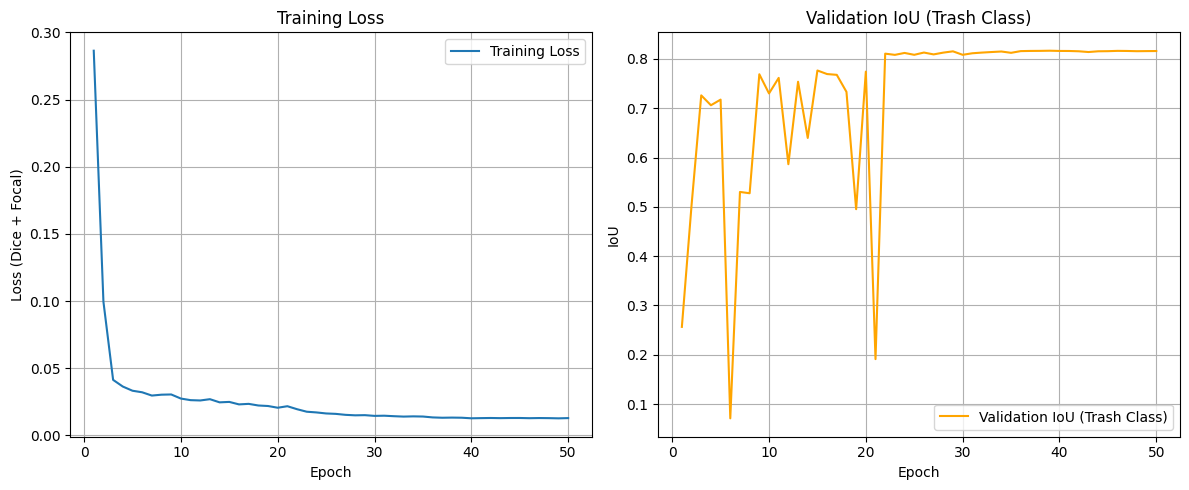


Zipping the plot...
Plot saved to /content/unet_training_plot.zip


In [ ]:
# CODE BLOCK 4: PLOT TRAINING HISTORY

import matplotlib.pyplot as plt
import os

print("\n--- Plotting Training History ---")

if 'history' in locals() and history['train_loss'] and history['val_iou']:
    epochs_range = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Training Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Training Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (Dice + Focal)')
    plt.legend()
    plt.grid(True)

    # Plot Validation IoU
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['val_iou'], label='Validation IoU (Trash Class)', color='orange')
    plt.title('Validation IoU (Trash Class)')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    # Save the plot
    plot_save_path = "/content/unet_training_history.png"
    plt.savefig(plot_save_path)
    print(f"Training history plot saved to: {plot_save_path}")
    plt.show()

    # --- Zip the plot ---
    print("\nZipping the plot...")
    !zip -j /content/unet_training_plot.zip {plot_save_path} -q # -j junks path
    print(f"Plot saved to /content/unet_training_plot.zip")


else:
    print("ERROR: Training history not found or is empty. Cannot plot.")

In [ ]:
# CODE BLOCK 5: GENERATE PREDICTION VISUALIZATIONS (Corrected Syntax)

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
import os
import glob
import cv2
from tqdm.notebook import tqdm
import scipy.io # Need scipy to load .mat for input visualization
import shutil # For rmtree

print("\n--- Generating Prediction Visualizations ---")

# --- 1. Load Best Model ---
best_model_path = "unet_best_model.pt" # Assumes this was saved by Block 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Re-define the model structure (must match the trained model)
model = smp.Unet("resnet34", encoder_weights=None, in_channels=3, classes=2)

if not os.path.exists(best_model_path):
    print(f"ERROR: Best model not found at {best_model_path}. Cannot generate visualizations.")
else:
    try:
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        model.to(device); model.eval(); print("Best U-Net model loaded.")
    except Exception as e:
        print(f"Error loading model state_dict: {e}")
        model = None # Flag failure

    # --- 2. Define Paths & Get Validation Samples ---
    VIS_OUTPUT_DIR = '/content/unet_predictions'
    NUM_SAMPLES = 10 # Number of samples to visualize

    # Need access to the validation dataset list (val_dataset) created in Block 2
    if 'val_dataset' not in locals() or len(val_dataset) == 0:
         print("ERROR: Validation dataset ('val_dataset') not found or empty.")
         print("Please ensure CODE BLOCK 2 (Preprocessing) ran successfully in this session.")
    elif model is None:
         print("ERROR: Model not loaded correctly. Cannot proceed.")
    else:
        if os.path.exists(VIS_OUTPUT_DIR): shutil.rmtree(VIS_OUTPUT_DIR)
        os.makedirs(VIS_OUTPUT_DIR)

        print(f"Processing up to {NUM_SAMPLES} validation samples for visualization...")

        # --- 3. Process Samples ---
        samples_processed = 0
        # Iterate through the validation dataset indices
        indices_to_process = range(min(NUM_SAMPLES, len(val_dataset)))

        for i in tqdm(indices_to_process, desc="Generating Visualizations"):
            try:
                # Get data using the dataset's __getitem__
                # This returns the *transformed* tensors for model input
                input_tensor, label_tensor = val_dataset[i] # Label is 0/1, H, W

                # Get original file paths from the dataset object for visualization
                # Assuming val_dataset is an instance of RadarDataset defined earlier
                original_mat_path = val_dataset.data_paths[i]
                original_mask_path = val_dataset.label_paths[i]
                base_name = os.path.splitext(os.path.basename(original_mat_path))[0]
                # Try to get sequence name robustly
                try:
                    seq_name = os.path.basename(os.path.dirname(os.path.dirname(original_mat_path)))
                except:
                    seq_name = "unknown_seq" # Fallback
                output_filename = f"{seq_name}_{base_name}_pred.png"
                output_path = os.path.join(VIS_OUTPUT_DIR, output_filename)

                # --- Load Original Input (.mat) for display ---
                mat_data = scipy.io.loadmat(original_mat_path)
                data_key = 'rdm'; # Default guess
                if data_key not in mat_data:
                    for key in mat_data:
                         if not key.startswith('__'): data_key = key; break
                if data_key not in mat_data: raise ValueError("RDM key not found")
                input_array = mat_data[data_key].astype(np.float32)
                if input_array.ndim > 2: input_array = input_array[0]
                if np.max(input_array) > np.min(input_array):
                     input_display = cv2.normalize(input_array, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
                else: input_display = np.zeros_like(input_array, dtype=np.uint8)
                input_display_rgb = cv2.cvtColor(input_display, cv2.COLOR_GRAY2RGB)

                # --- Load Original Mask (.png) for display ---
                gt_mask_pil = Image.open(original_mask_path).convert("L")
                gt_mask_display = np.array(gt_mask_pil) # Should be 0 or 255
                gt_mask_rgb = cv2.cvtColor(gt_mask_display, cv2.COLOR_GRAY2RGB)

                # --- Run Prediction ---
                input_batch = input_tensor.unsqueeze(0).to(device) # Add batch dim
                with torch.no_grad():
                    output_logits = model(input_batch) # B, C, H, W
                    pred_mask = torch.argmax(output_logits, dim=1).squeeze(0).cpu().numpy() # H, W (0 or 1)

                # --- Prepare Prediction Mask for Display ---
                pred_mask_display = (pred_mask * 255).astype(np.uint8) # Convert 0/1 to 0/255
                pred_mask_rgb = cv2.cvtColor(pred_mask_display, cv2.COLOR_GRAY2RGB)

                # --- Create Side-by-Side Visualization ---
                # Resize all to the same size (e.g., dataset input size 256x256)
                h, w = val_dataset.img_size
                input_display_resized = cv2.resize(input_display_rgb, (w,h), interpolation=cv2.INTER_NEAREST)
                gt_mask_resized = cv2.resize(gt_mask_rgb, (w,h), interpolation=cv2.INTER_NEAREST)
                pred_mask_resized = cv2.resize(pred_mask_rgb, (w,h), interpolation=cv2.INTER_NEAREST)

                # Add titles
                font = cv2.FONT_HERSHEY_SIMPLEX; font_scale = 0.4; color=(200,200,0); thickness=1 # Yellow text
                cv2.putText(input_display_resized, 'Input (Radar Mat)', (5, 15), font, font_scale, color, thickness)
                cv2.putText(gt_mask_resized, 'Ground Truth Mask', (5, 15), font, font_scale, color, thickness)
                cv2.putText(pred_mask_resized, 'U-Net Prediction', (5, 15), font, font_scale, color, thickness)

                # Concatenate images horizontally
                comparison_img = np.concatenate((input_display_resized, gt_mask_resized, pred_mask_resized), axis=1)

                # --- Save Comparison Image ---
                Image.fromarray(comparison_img).save(output_path)
                samples_processed += 1

            except FileNotFoundError as fnf_err:
                 print(f"Skipping sample {i} due to missing file: {fnf_err}")
            except Exception as e:
                # Use index 'i' as dataset index might not be available if error occurs early
                print(f"Error generating visualization for sample index {i}: {e}")


        if samples_processed > 0:
            print(f"\n--- Prediction Visualizations Generated ---")
            print(f"Comparison images saved to: {VIS_OUTPUT_DIR}")
            print("Zipping prediction images...")
            # --- FIX: Split print and shell command ---
            !zip -r /content/unet_prediction_images.zip {VIS_OUTPUT_DIR} -q
            # --- END FIX ---
            print("Saved to /content/unet_prediction_images.zip")
            print("Download from the 'Files' tab.")
        elif len(val_dataset) > 0: # Check if dataset was non-empty
             print("No prediction visualizations were generated. Check for errors during processing.")# CODE BLOCK 5: GENERATE PREDICTION VISUALIZATIONS (Corrected Syntax)

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
import os
import glob
import cv2
from tqdm.notebook import tqdm
import scipy.io # Need scipy to load .mat for input visualization
import shutil # For rmtree

print("\n--- Generating Prediction Visualizations ---")

# --- 1. Load Best Model ---
best_model_path = "unet_best_model.pt" # Assumes this was saved by Block 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Re-define the model structure (must match the trained model)
model = smp.Unet("resnet34", encoder_weights=None, in_channels=3, classes=2)

if not os.path.exists(best_model_path):
    print(f"ERROR: Best model not found at {best_model_path}. Cannot generate visualizations.")
else:
    try:
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        model.to(device); model.eval(); print("Best U-Net model loaded.")
    except Exception as e:
        print(f"Error loading model state_dict: {e}")
        model = None # Flag failure

    # --- 2. Define Paths & Get Validation Samples ---
    VIS_OUTPUT_DIR = '/content/unet_predictions'
    NUM_SAMPLES = 10 # Number of samples to visualize

    # Need access to the validation dataset list (val_dataset) created in Block 2
    if 'val_dataset' not in locals() or len(val_dataset) == 0:
         print("ERROR: Validation dataset ('val_dataset') not found or empty.")
         print("Please ensure CODE BLOCK 2 (Preprocessing) ran successfully in this session.")
    elif model is None:
         print("ERROR: Model not loaded correctly. Cannot proceed.")
    else:
        if os.path.exists(VIS_OUTPUT_DIR): shutil.rmtree(VIS_OUTPUT_DIR)
        os.makedirs(VIS_OUTPUT_DIR)

        print(f"Processing up to {NUM_SAMPLES} validation samples for visualization...")

        # --- 3. Process Samples ---
        samples_processed = 0
        # Iterate through the validation dataset indices
        indices_to_process = range(min(NUM_SAMPLES, len(val_dataset)))

        for i in tqdm(indices_to_process, desc="Generating Visualizations"):
            try:
                # Get data using the dataset's __getitem__
                # This returns the *transformed* tensors for model input
                input_tensor, label_tensor = val_dataset[i] # Label is 0/1, H, W

                # Get original file paths from the dataset object for visualization
                # Assuming val_dataset is an instance of RadarDataset defined earlier
                original_mat_path = val_dataset.data_paths[i]
                original_mask_path = val_dataset.label_paths[i]
                base_name = os.path.splitext(os.path.basename(original_mat_path))[0]
                # Try to get sequence name robustly
                try:
                    seq_name = os.path.basename(os.path.dirname(os.path.dirname(original_mat_path)))
                except:
                    seq_name = "unknown_seq" # Fallback
                output_filename = f"{seq_name}_{base_name}_pred.png"
                output_path = os.path.join(VIS_OUTPUT_DIR, output_filename)

                # --- Load Original Input (.mat) for display ---
                mat_data = scipy.io.loadmat(original_mat_path)
                data_key = 'rdm'; # Default guess
                if data_key not in mat_data:
                    for key in mat_data:
                         if not key.startswith('__'): data_key = key; break
                if data_key not in mat_data: raise ValueError("RDM key not found")
                input_array = mat_data[data_key].astype(np.float32)
                if input_array.ndim > 2: input_array = input_array[0]
                if np.max(input_array) > np.min(input_array):
                     input_display = cv2.normalize(input_array, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
                else: input_display = np.zeros_like(input_array, dtype=np.uint8)
                input_display_rgb = cv2.cvtColor(input_display, cv2.COLOR_GRAY2RGB)

                # --- Load Original Mask (.png) for display ---
                gt_mask_pil = Image.open(original_mask_path).convert("L")
                gt_mask_display = np.array(gt_mask_pil) # Should be 0 or 255
                gt_mask_rgb = cv2.cvtColor(gt_mask_display, cv2.COLOR_GRAY2RGB)

                # --- Run Prediction ---
                input_batch = input_tensor.unsqueeze(0).to(device) # Add batch dim
                with torch.no_grad():
                    output_logits = model(input_batch) # B, C, H, W
                    pred_mask = torch.argmax(output_logits, dim=1).squeeze(0).cpu().numpy() # H, W (0 or 1)

                # --- Prepare Prediction Mask for Display ---
                pred_mask_display = (pred_mask * 255).astype(np.uint8) # Convert 0/1 to 0/255
                pred_mask_rgb = cv2.cvtColor(pred_mask_display, cv2.COLOR_GRAY2RGB)

                # --- Create Side-by-Side Visualization ---
                # Resize all to the same size (e.g., dataset input size 256x256)
                h, w = val_dataset.img_size
                input_display_resized = cv2.resize(input_display_rgb, (w,h), interpolation=cv2.INTER_NEAREST)
                gt_mask_resized = cv2.resize(gt_mask_rgb, (w,h), interpolation=cv2.INTER_NEAREST)
                pred_mask_resized = cv2.resize(pred_mask_rgb, (w,h), interpolation=cv2.INTER_NEAREST)

                # Add titles
                font = cv2.FONT_HERSHEY_SIMPLEX; font_scale = 0.4; color=(200,200,0); thickness=1 # Yellow text
                cv2.putText(input_display_resized, 'Input (Radar Mat)', (5, 15), font, font_scale, color, thickness)
                cv2.putText(gt_mask_resized, 'Ground Truth Mask', (5, 15), font, font_scale, color, thickness)
                cv2.putText(pred_mask_resized, 'U-Net Prediction', (5, 15), font, font_scale, color, thickness)

                # Concatenate images horizontally
                comparison_img = np.concatenate((input_display_resized, gt_mask_resized, pred_mask_resized), axis=1)

                # --- Save Comparison Image ---
                Image.fromarray(comparison_img).save(output_path)
                samples_processed += 1

            except FileNotFoundError as fnf_err:
                 print(f"Skipping sample {i} due to missing file: {fnf_err}")
            except Exception as e:
                # Use index 'i' as dataset index might not be available if error occurs early
                print(f"Error generating visualization for sample index {i}: {e}")


        if samples_processed > 0:
            print(f"\n--- Prediction Visualizations Generated ---")
            print(f"Comparison images saved to: {VIS_OUTPUT_DIR}")
            print("Zipping prediction images...")
            # --- FIX: Split print and shell command ---
            !zip -r /content/unet_prediction_images.zip {VIS_OUTPUT_DIR} -q
            # --- END FIX ---
            print("Saved to /content/unet_prediction_images.zip")
            print("Download from the 'Files' tab.")
        elif len(val_dataset) > 0: # Check if dataset was non-empty
             print("No prediction visualizations were generated. Check for errors during processing.")


--- Generating Prediction Visualizations ---
Best U-Net model loaded.
Processing up to 10 validation samples for visualization...


Generating Visualizations:   0%|          | 0/10 [00:00<?, ?it/s]


--- Prediction Visualizations Generated ---
Comparison images saved to: /content/unet_predictions
Zipping prediction images...
Saved to /content/unet_prediction_images.zip
Download from the 'Files' tab.

--- Generating Prediction Visualizations ---
Best U-Net model loaded.
Processing up to 10 validation samples for visualization...


Generating Visualizations:   0%|          | 0/10 [00:00<?, ?it/s]


--- Prediction Visualizations Generated ---
Comparison images saved to: /content/unet_predictions
Zipping prediction images...
Saved to /content/unet_prediction_images.zip
Download from the 'Files' tab.


Above was just the detection of the objects


DBSCAN

Scanning for all point cloud files...
Found 2227 point cloud files in total.
Running DBSCAN Clustering on 2227 files...


  0%|          | 0/2227 [00:00<?, ?it/s]


MODEL 3: DBSCAN Results
Total Files Processed: 2227
Total Objects Detected: 6280
Average Objects per Frame: 2.82

Saved heatmap to: dbscan_density_heatmap.png


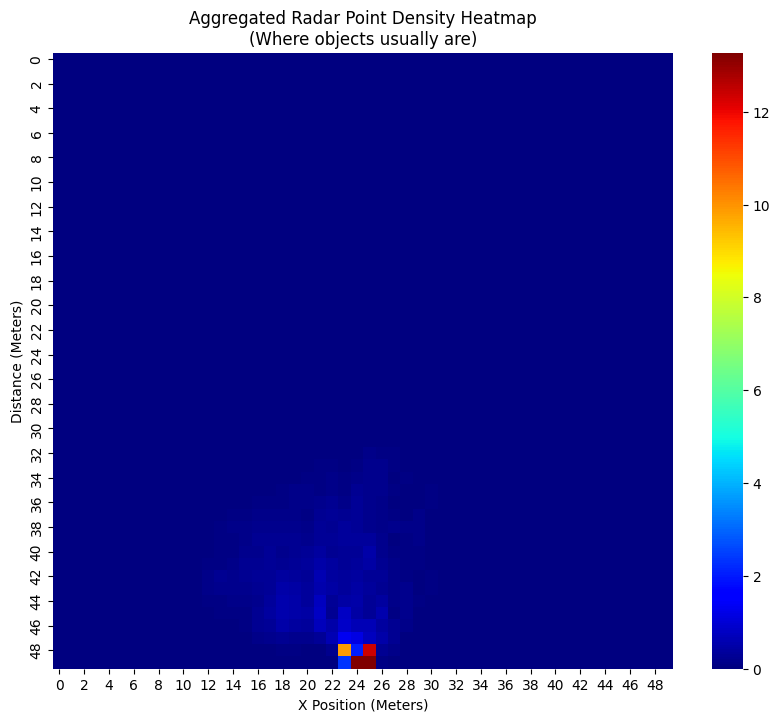

In [8]:
# CODE BLOCK 2: RUN DBSCAN MODEL (Corrected to find ALL files)

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from tqdm.notebook import tqdm
import seaborn as sns

# --- 1. Find ALL Point Cloud Files ---
DATA_DIR = '/content/FloW_RI_Dataset' # Base folder
all_pc_files = []

print("Scanning for all point cloud files...")
for root, dirs, files in os.walk(DATA_DIR):
    # Look for the specific subfolder in every directory
    if 'Radar_Point_Cloud_Data' in dirs:
        pc_dir = os.path.join(root, 'Radar_Point_Cloud_Data')
        # Add all .txt files from this folder to our list
        for f in os.listdir(pc_dir):
            if f.endswith('.txt'):
                all_pc_files.append(os.path.join(pc_dir, f))

print(f"Found {len(all_pc_files)} point cloud files in total.")

# --- 2. Run DBSCAN ---
# Parameters for DBSCAN (Tune these!)
EPSILON = 1.5
MIN_SAMPLES = 3

total_objects_detected = 0
heatmaps = []

# We will process ALL files now (or set a limit like [:500] if it takes too long)
print(f"Running DBSCAN Clustering on {len(all_pc_files)} files...")

for path in tqdm(all_pc_files):
    try:
        # Load X, Y coordinates
        points = np.loadtxt(path, usecols=(0, 1))
        if len(points.shape) == 1: points = points.reshape(1, -1)

        if len(points) > 0:
            # --- MODEL: DBSCAN ---
            clustering = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES).fit(points)
            labels = clustering.labels_

            # Count clusters (ignoring noise which is -1)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            total_objects_detected += n_clusters

            # --- GENERATE HEATMAP DATA ---
            # Create a 2D histogram for this frame
            heatmap, xedges, yedges = np.histogram2d(
                points[:, 0], points[:, 1],
                bins=50, range=[[-20, 20], [0, 40]]
            )
            heatmaps.append(heatmap)

    except Exception as e: pass

# --- 3. Results & Visualization ---
print("\n" + "="*30)
print(f"MODEL 3: DBSCAN Results")
print("="*30)
print(f"Total Files Processed: {len(all_pc_files)}")
print(f"Total Objects Detected: {total_objects_detected}")
if len(all_pc_files) > 0:
    print(f"Average Objects per Frame: {total_objects_detected/len(all_pc_files):.2f}")

if len(heatmaps) > 0:
    avg_heatmap = np.mean(heatmaps, axis=0)

    plt.figure(figsize=(10, 8))
    sns.heatmap(np.rot90(avg_heatmap), cmap="jet", vmax=np.max(avg_heatmap)*0.5)
    plt.title(f"Aggregated Radar Point Density Heatmap\n(Where objects usually are)")
    plt.xlabel("X Position (Meters)")
    plt.ylabel("Distance (Meters)")

    plt.savefig('dbscan_density_heatmap.png')
    print("\nSaved heatmap to: dbscan_density_heatmap.png")
    plt.show()

Analyzing distances for 2227 files...


  0%|          | 0/2227 [00:00<?, ?it/s]


DISTANCE ESTIMATION RESULTS
Total Objects Analyzed: 4294
Average Distance:       7.84 meters
Closest Object:         1.00 meters
Furthest Object:        14.26 meters

Saved analysis plot to: distance_analysis.png


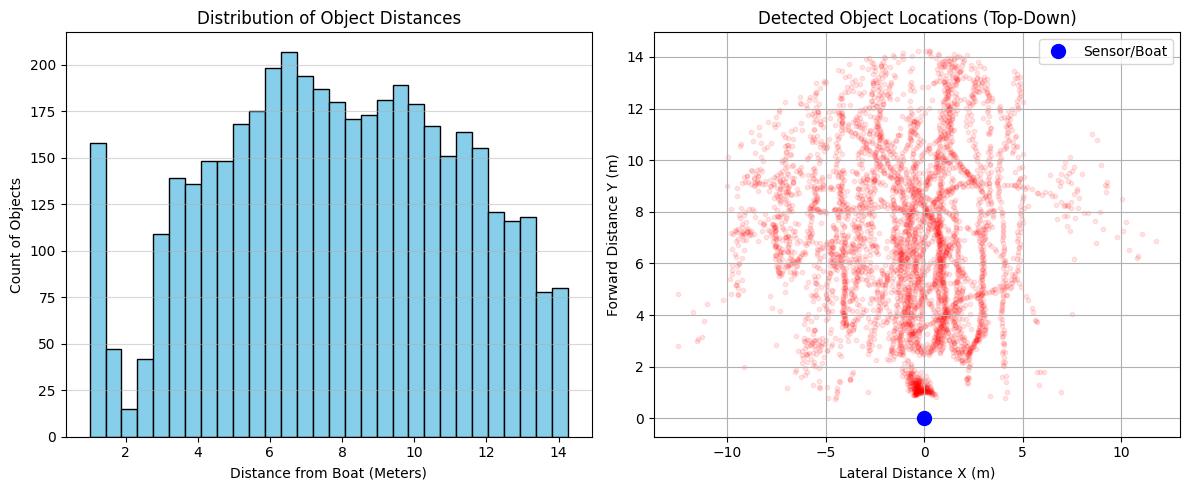

In [9]:
# CODE BLOCK: MODEL 3 (Part 2) - Distance Estimation

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from tqdm.notebook import tqdm
import seaborn as sns

# --- Config ---
# Tune these based on your specific radar resolution
EPSILON = 1.5   # Neighbor distance (meters)
MIN_SAMPLES = 3 # Min points for a cluster

# --- Lists to store results ---
all_object_distances = []
object_positions_x = []
object_positions_y = []

print(f"Analyzing distances for {len(all_pc_files)} files...")

for path in tqdm(all_pc_files):
    try:
        # Load X, Y coordinates (Meters)
        points = np.loadtxt(path, usecols=(0, 1))
        if len(points.shape) == 1: points = points.reshape(1, -1)

        if len(points) > 0:
            # 1. Run Clustering
            clustering = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES).fit(points)
            labels = clustering.labels_
            unique_labels = set(labels)

            # 2. Analyze Each Cluster (Object)
            for label in unique_labels:
                if label == -1: continue # Skip noise

                # Get all points belonging to this specific object
                obj_points = points[labels == label]

                # Calculate the CENTROID (Center of the object)
                center_x = np.mean(obj_points[:, 0])
                center_y = np.mean(obj_points[:, 1])

                # Calculate Euclidean Distance from Sensor (0,0)
                distance = np.sqrt(center_x**2 + center_y**2)

                # Filter out the "Self-Reflection" noise near 0
                # (Trash is unlikely to be closer than 0.5 meters)
                if distance > 1.0:
                    all_object_distances.append(distance)
                    object_positions_x.append(center_x)
                    object_positions_y.append(center_y)

    except Exception as e: pass

# --- 3. Report Results ---
num_objects = len(all_object_distances)
avg_distance = np.mean(all_object_distances) if num_objects > 0 else 0
min_dist = np.min(all_object_distances) if num_objects > 0 else 0
max_dist = np.max(all_object_distances) if num_objects > 0 else 0

print("\n" + "="*30)
print(f"DISTANCE ESTIMATION RESULTS")
print("="*30)
print(f"Total Objects Analyzed: {num_objects}")
print(f"Average Distance:       {avg_distance:.2f} meters")
print(f"Closest Object:         {min_dist:.2f} meters")
print(f"Furthest Object:        {max_dist:.2f} meters")

# --- 4. Visualization: Distance Histogram ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(all_object_distances, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Object Distances")
plt.xlabel("Distance from Boat (Meters)")
plt.ylabel("Count of Objects")
plt.grid(axis='y', alpha=0.5)

# --- 5. Visualization: Top-Down Detection Map ---
plt.subplot(1, 2, 2)
plt.scatter(object_positions_x, object_positions_y, alpha=0.1, s=10, c='red')
plt.plot(0, 0, 'bo', markersize=10, label='Sensor/Boat') # Mark the boat
plt.title("Detected Object Locations (Top-Down)")
plt.xlabel("Lateral Distance X (m)")
plt.ylabel("Forward Distance Y (m)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('distance_analysis.png')
print("\nSaved analysis plot to: distance_analysis.png")
plt.show()

In [10]:
# CODE BLOCK: MODEL 3 (Final) - DBSCAN with Evaluation Metrics

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from tqdm.notebook import tqdm
import seaborn as sns

# --- Config ---
EPSILON = 1.5   # Neighbor distance (meters)
MIN_SAMPLES = 3 # Min points for a cluster

# --- Metrics Storage ---
silhouette_scores = []
noise_ratios = []
cluster_sizes = []
total_objects = 0

print(f"Evaluating DBSCAN on {len(all_pc_files)} files...")

for path in tqdm(all_pc_files):
    try:
        # Load X, Y coordinates (Meters)
        points = np.loadtxt(path, usecols=(0, 1))
        if len(points.shape) == 1: points = points.reshape(1, -1)

        if len(points) > MIN_SAMPLES: # Need enough points to calculate metrics
            # 1. Run Clustering
            clustering = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES).fit(points)
            labels = clustering.labels_

            # 2. Calculate Silhouette Score (Only if > 1 cluster and > 1 label type exist)
            # (Silhouette requires at least 2 defined clusters or 1 cluster + noise)
            unique_labels = set(labels)
            if len(unique_labels) > 1:
                score = silhouette_score(points, labels)
                silhouette_scores.append(score)

            # 3. Calculate Noise Ratio
            n_noise = list(labels).count(-1)
            noise_ratio = n_noise / len(points)
            noise_ratios.append(noise_ratio)

            # 4. Calculate Cluster Stats
            n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
            total_objects += n_clusters

            for label in unique_labels:
                if label != -1:
                    size = np.sum(labels == label)
                    cluster_sizes.append(size)

    except Exception as e: pass

# --- 4. Print Final Evaluation Report ---
avg_silhouette = np.mean(silhouette_scores) if silhouette_scores else 0.0
avg_noise = np.mean(noise_ratios) if noise_ratios else 0.0
avg_size = np.mean(cluster_sizes) if cluster_sizes else 0.0

print("\n" + "="*40)
print(f"MODEL 3: UNSUPERVISED EVALUATION REPORT")
print("="*40)
print(f"1. Silhouette Score:    {avg_silhouette:.4f}  (Higher is better, max 1.0)")
print(f"   -> Indicates how distinct the trash objects are from the noise.")
print("-" * 40)
print(f"2. Noise Ratio:         {avg_noise*100:.2f}%")
print(f"   -> Percentage of radar returns classified as water clutter.")
print("-" * 40)
print(f"3. Object Statistics:")
print(f"   - Total Objects Found: {total_objects}")
print(f"   - Avg Points per Obj:  {avg_size:.1f}")
print("="*40)

Evaluating DBSCAN on 2227 files...


  0%|          | 0/2227 [00:00<?, ?it/s]


MODEL 3: UNSUPERVISED EVALUATION REPORT
1. Silhouette Score:    0.8105  (Higher is better, max 1.0)
   -> Indicates how distinct the trash objects are from the noise.
----------------------------------------
2. Noise Ratio:         0.49%
   -> Percentage of radar returns classified as water clutter.
----------------------------------------
3. Object Statistics:
   - Total Objects Found: 6280
   - Avg Points per Obj:  48.0


In [11]:
# CODE BLOCK: GENERATE DBSCAN VISUALIZATIONS

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
import shutil
from sklearn.cluster import DBSCAN
from tqdm.notebook import tqdm

# --- Config ---
VIS_DIR = '/content/dbscan_visualizations'
if os.path.exists(VIS_DIR): shutil.rmtree(VIS_DIR)
os.makedirs(VIS_DIR)

# DBSCAN Settings (Same as before)
EPSILON = 1.5
MIN_SAMPLES = 3

# How many images to generate?
# Set to len(all_pc_files) for ALL images (takes longer)
NUM_SAMPLES = 50

print(f"Generating {NUM_SAMPLES} visualization images...")

# Loop through files
for i, path in enumerate(tqdm(all_pc_files[:NUM_SAMPLES])):
    try:
        # 1. Load Points
        points = np.loadtxt(path, usecols=(0, 1))
        if len(points.shape) == 1: points = points.reshape(1, -1)

        if len(points) > 0:
            # 2. Run Clustering
            clustering = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES).fit(points)
            labels = clustering.labels_
            unique_labels = set(labels)

            # 3. Create Plot
            fig, ax = plt.subplots(figsize=(8, 8))

            # Plot Noise (Label -1) in Grey
            noise_points = points[labels == -1]
            ax.scatter(noise_points[:, 0], noise_points[:, 1], c='lightgrey', s=10, label='Noise/Water')

            # Plot Sensor Location
            ax.plot(0, 0, 'bx', markersize=12, label='Boat/Sensor')

            object_count = 0

            # 4. Loop through found clusters (The "Objects")
            for label in unique_labels:
                if label == -1: continue # Skip noise

                # Get points for this specific object
                obj_points = points[labels == label]

                # Calculate Bounding Box coordinates
                x_min, x_max = np.min(obj_points[:, 0]), np.max(obj_points[:, 0])
                y_min, y_max = np.min(obj_points[:, 1]), np.max(obj_points[:, 1])
                width = x_max - x_min
                height = y_max - y_min

                # Add padding to box for visibility
                pad = 0.5

                # Draw Red Rectangle (The "Marker")
                rect = patches.Rectangle(
                    (x_min - pad/2, y_min - pad/2),
                    width + pad, height + pad,
                    linewidth=2, edgecolor='red', facecolor='none'
                )
                ax.add_patch(rect)

                # Plot the object points in Red
                ax.scatter(obj_points[:, 0], obj_points[:, 1], c='red', s=20)

                object_count += 1

            # Formatting
            seq_name = os.path.basename(os.path.dirname(os.path.dirname(path)))
            base_name = os.path.basename(path).replace('.txt', '')

            ax.set_title(f"Seq: {seq_name} | Frame: {base_name}\nObjects Detected: {object_count}")
            ax.set_xlabel("Lateral Distance (Meters)")
            ax.set_ylabel("Forward Distance (Meters)")
            ax.set_xlim(-15, 15) # Fixed view width
            ax.set_ylim(0, 30)   # Fixed view distance
            ax.grid(True, alpha=0.3)

            # Save and close
            save_path = os.path.join(VIS_DIR, f"{seq_name}_{base_name}_vis.png")
            plt.savefig(save_path)
            plt.close(fig) # Close to free memory

    except Exception as e:
        print(f"Error on {path}: {e}")

print("\n--- Visualization Complete ---")
print("Zipping images...")
!zip -r /content/dbscan_visualizations.zip {VIS_DIR} -q
print("Saved to /content/dbscan_visualizations.zip")
print("Download this zip file to see the objects marked with red boxes.")

Generating 50 visualization images...


  0%|          | 0/50 [00:00<?, ?it/s]


--- Visualization Complete ---
Zipping images...
Saved to /content/dbscan_visualizations.zip
Download this zip file to see the objects marked with red boxes.


In [12]:
from google.colab import files

# This will pop up a download prompt in your browser
files.download('/content/dbscan_visualizations.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>